In [2]:
import jax.numpy as jnp


In [25]:
data = jnp.load('./data_assignment3.npz')
x, y = data['x'], data['t']

In [49]:
from scipy.stats import norm
import jax.numpy as jnp

sigmoid = lambda x: 1./(1 + jnp.exp(-x))

def halfnormal(x):
    if x < 0:
        return 0
    else:
        return 2*norm.pdf(x, 0, 1)

def log_halfnormal(x):
    if x < 0:
        return -jnp.inf
    else:
        return jnp.log(2) + norm.logpdf(x, 0, 1)

def unpack(params):
    w1 = params[:2]
    w2 = params[2:4]
    v = params[4:6]
    tau = params[6]
    sigma1 = params[7]
    sigma2 = params[8]
    return w1, w2, v, tau, sigma1, sigma2

def log_likelihood(X, y, params):
    w1, w2, v, tau, sigma1, sigma2 = unpack(params)
    g = X@v
    f1 = X@w1
    f2 = X@w2
    pi = sigmoid(g)
    if tau > 0 and sigma1 > 0 and sigma2 > 0:
        log_c1 = jnp.log(1 - pi) + norm.logpdf(y, f1, sigma1)
        log_c2 = jnp.log(pi)     + norm.logpdf(y, f2, sigma2)
        # logsumexp for numerical stability
        log_mix = jnp.logaddexp(log_c1, log_c2)
        return log_mix.sum()
        # return jnp.log((1-pi)*norm.pdf(y, f1, sigma1) + pi*norm.pdf(y, f2, sigma2)).sum()
    else:
        return -jnp.inf

def log_prior(params):
    w1, w2, v, tau, sigma1, sigma2 = unpack(params)
    log_p = log_halfnormal(tau) + log_halfnormal(sigma2) + log_halfnormal(sigma1)
    log_p += norm.logpdf(w1, 0, tau).sum() + norm.logpdf(w2, 0, tau).sum() + norm.logpdf(v, 0, tau).sum()       
    return log_p

# precompute design matrix
N = len(x)
X = jnp.column_stack((x, jnp.ones(N)))

# define log joint
log_joint_data = lambda X, y, params: log_likelihood(X, y, params) + log_prior(params)
log_joint = lambda p: log_joint_data(X, y, p)

In [51]:
from jax import random 
import numpy as np
from tqdm import tqdm

def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=42):    
    """ Runs a Metropolis-Hastings sampler 
    
        Arguments:
        log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
        num_params:         number of parameters of the joint distribution (integer)
        tau:                standard deviation of the Gaussian proposal distribution (positive real)
        num_iter:           number of iterations (integer)
        theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
        seed:               seed (integer)

        returns
        thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
    """ 
    
    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.ones((num_params))
    
    # prepare lists 
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)
    
    for k in tqdm(range(num_iter)):

        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)

        ##############################################
        # Your solution goes here
        ##############################################
        theta_next = random.normal(key_proposal, (num_params,)) * tau + thetas[k]
        log_p_theta_next = log_target(theta_next)

        r = log_p_theta_next - log_p_theta

        A = jnp.minimum(1., jnp.exp(r))

        u = random.uniform(key_accept)

        if u < A:
            accepts.append(1)
            log_p_theta = log_p_theta_next
        else:
            theta_next = thetas[k]
            accepts.append(0)

        if k % 3000 == 0:
            print(f'Iteration {k}, acceptance rate: {jnp.mean(jnp.array(accepts)):.3f}')

        ##############################################
        # End of solution
        ##############################################
            
        thetas.append(theta_next)

    print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
        
    # return as np.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
    return thetas


# sanity check: estimate the mean and variance of a N(x|1,3) Gaussian distribution
p_target = log_joint

# run sampler
thetas = metropolis(p_target, 9, 0.1, 50000, seed=123)

  0%|          | 139/50000 [00:00<01:10, 710.87it/s]

Iteration 0, acceptance rate: 0.000


  6%|▋         | 3154/50000 [00:04<00:57, 808.44it/s]

Iteration 3000, acceptance rate: 0.289


 12%|█▏        | 6098/50000 [00:07<00:54, 806.77it/s]

...

Iteration 45000, acceptance rate: 0.277


 96%|█████████▋| 48136/50000 [01:00<00:02, 743.82it/s]

Iteration 48000, acceptance rate: 0.277


100%|██████████| 50000/50000 [01:02<00:00, 796.83it/s]


Acceptance ratio: 0.28


In [55]:
params_samples_after_warmup = thetas[len(thetas)//2:, :]
num_params = params_samples_after_warmup.shape[1]
param_names = ['w0_1', 'w0_2', 'w1_1', 'w1_2', 'v_0', 'v_1', 'tau', 'sigma0', 'sigma1']
for i in range(num_params):
    # compute mean
    m = jnp.mean(params_samples_after_warmup[:, i])
    # intervals
    lower, upper = jnp.percentile(params_samples_after_warmup[:, i], jnp.array([2.5, 97.5]))
    print(f'{param_names[i]:15s} Mean = {m:+4.3f}\tInterval = [{lower:+4.3f}, {upper:+4.3f}]')

w0_1            Mean = +1.478	Interval = [+1.352, +1.596]
w0_2            Mean = +1.002	Interval = [+0.631, +1.362]
w1_1            Mean = -1.822	Interval = [-2.433, -1.340]
w1_2            Mean = -2.079	Interval = [-3.696, +0.008]
v_0             Mean = +2.580	Interval = [+1.563, +4.034]
v_1             Mean = -1.529	Interval = [-2.492, -0.626]
tau             Mean = +1.664	Interval = [+1.044, +2.519]
sigma0          Mean = +1.389	Interval = [+1.221, +1.584]
sigma1          Mean = +4.504	Interval = [+3.970, +5.140]


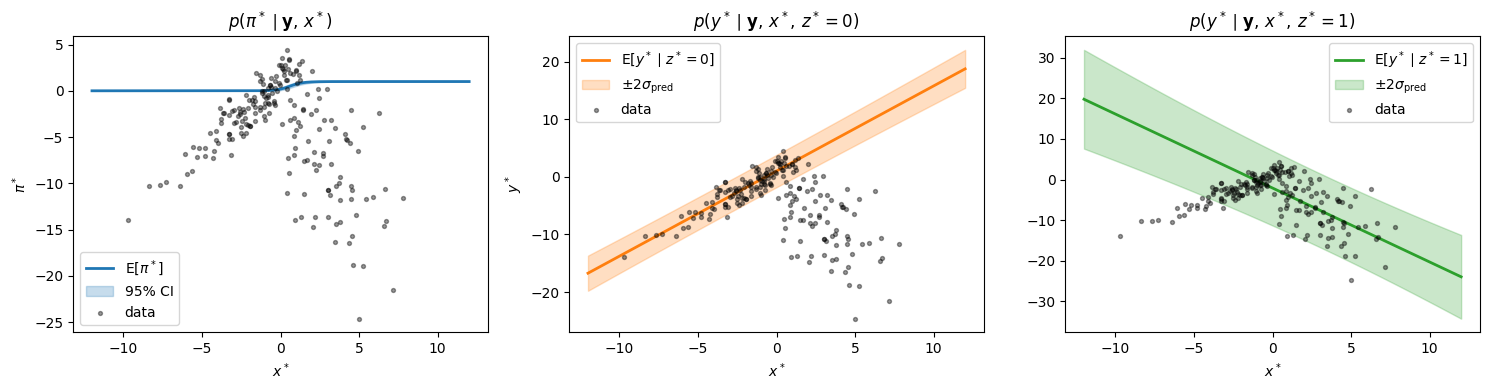

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# use post-warmup samples
samples = np.array(params_samples_after_warmup)   # (S, 9)

x_star  = np.linspace(-12, 12, 300)
X_star  = np.column_stack([x_star, np.ones(300)]) # (300, 2)

# vectorised extraction  →  (S, 2) each
W1     = samples[:, 0:2]
W2     = samples[:, 2:4]
V      = samples[:, 4:6]
Sigma1 = samples[:, 7]   # (S,)
Sigma2 = samples[:, 8]   # (S,)

# predictions for all samples and all test points  →  (S, 300)
F1 = W1 @ X_star.T
F2 = W2 @ X_star.T
PI = 1. / (1 + np.exp(-(V @ X_star.T)))   # sigmoid

# ---------- p(π* | y, x*) ----------
pi_mean  = PI.mean(axis=0)
pi_lower = np.percentile(PI,  2.5, axis=0)
pi_upper = np.percentile(PI, 97.5, axis=0)

# ---------- p(y* | y, x*, z*=k) ----------
# predictive variance = epistemic (var of means) + aleatoric (mean of variances)
f1_mean = F1.mean(axis=0)
f1_std  = np.sqrt(F1.var(axis=0) + (Sigma1**2).mean())

f2_mean = F2.mean(axis=0)
f2_std  = np.sqrt(F2.var(axis=0) + (Sigma2**2).mean())

# ---------- plot ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
data_kw = dict(c='k', s=8, alpha=0.4, zorder=5, label='data')

# p(π* | y, x*)
ax = axes[0]
ax.plot(x_star, pi_mean, 'C0', lw=2, label=r'$\mathrm{E}[\pi^*]$')
ax.fill_between(x_star, pi_lower, pi_upper, alpha=0.25, color='C0', label='95% CI')
ax.scatter(x, y, **data_kw)
ax.set_title(r'$p(\pi^* \mid \mathbf{y},\, x^*)$')
ax.set_xlabel('$x^*$'); ax.set_ylabel('$\pi^*$')
ax.legend()

# p(y* | y, x*, z*=0)
ax = axes[1]
ax.plot(x_star, f1_mean, 'C1', lw=2, label=r'$\mathrm{E}[y^* \mid z^*=0]$')
ax.fill_between(x_star, f1_mean - 2*f1_std, f1_mean + 2*f1_std,
                alpha=0.25, color='C1', label=r'$\pm 2\sigma_\mathrm{pred}$')
ax.scatter(x, y, **data_kw)
ax.set_title(r'$p(y^* \mid \mathbf{y},\, x^*,\, z^*=0)$')
ax.set_xlabel('$x^*$'); ax.set_ylabel('$y^*$')
ax.legend()

# p(y* | y, x*, z*=1)
ax = axes[2]
ax.plot(x_star, f2_mean, 'C2', lw=2, label=r'$\mathrm{E}[y^* \mid z^*=1]$')
ax.fill_between(x_star, f2_mean - 2*f2_std, f2_mean + 2*f2_std,
                alpha=0.25, color='C2', label=r'$\pm 2\sigma_\mathrm{pred}$')
ax.scatter(x, y, **data_kw)
ax.set_title(r'$p(y^* \mid \mathbf{y},\, x^*,\, z^*=1)$')
ax.set_xlabel('$x^*$')
ax.legend()

plt.tight_layout()
plt.show()


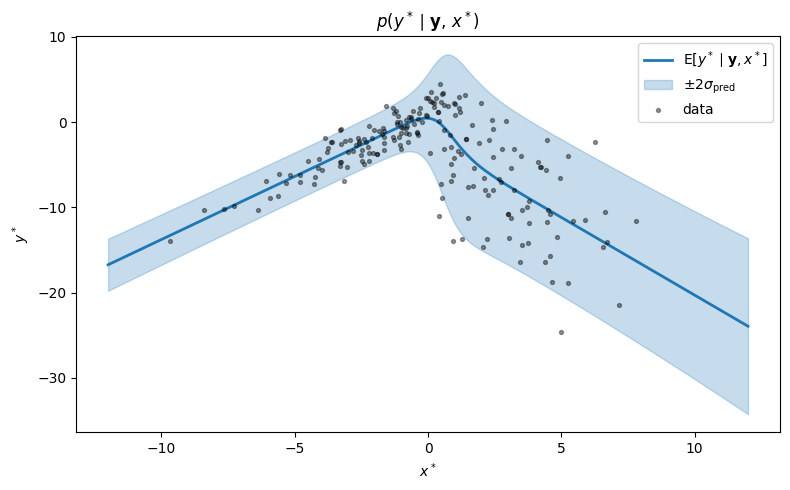

In [57]:
import matplotlib.pyplot as plt
import numpy as np

samples = np.array(params_samples_after_warmup)   # (S, 9)

x_star = np.linspace(-12, 12, 300)
X_star = np.column_stack([x_star, np.ones(300)])  # (300, 2)

W1     = samples[:, 0:2]   # (S, 2)
W2     = samples[:, 2:4]
V      = samples[:, 4:6]
Sigma1 = samples[:, 7]     # (S,)
Sigma2 = samples[:, 8]

# (S, 300)
F1 = W1 @ X_star.T
F2 = W2 @ X_star.T
PI = 1. / (1 + np.exp(-(V @ X_star.T)))           # sigmoid, (S, 300)

# per-sample conditional mean of y*  →  (S, 300)
cond_mean = (1 - PI) * F1 + PI * F2

# per-sample conditional variance of y* (law of total variance within each sample)
# Var[y*|θ,x*] = (1-π)σ1² + π·σ2² + π(1-π)(f2-f1)²
cond_var = (
    (1 - PI) * Sigma1[:, None]**2
    + PI      * Sigma2[:, None]**2
    + PI * (1 - PI) * (F2 - F1)**2
)

# posterior predictive mean and variance (law of total expectation/variance over θ)
pred_mean = cond_mean.mean(axis=0)                          # (300,)
pred_var  = cond_var.mean(axis=0) + cond_mean.var(axis=0)  # aleatoric + epistemic
pred_std  = np.sqrt(pred_var)

# plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_star, pred_mean, 'C0', lw=2, label=r'$\mathrm{E}[y^* \mid \mathbf{y}, x^*]$')
ax.fill_between(x_star,
                pred_mean - 2*pred_std,
                pred_mean + 2*pred_std,
                alpha=0.25, color='C0', label=r'$\pm 2\sigma_\mathrm{pred}$')
ax.scatter(x, y, c='k', s=8, alpha=0.4, zorder=5, label='data')
ax.set_title(r'$p(y^* \mid \mathbf{y},\, x^*)$')
ax.set_xlabel('$x^*$'); ax.set_ylabel('$y^*$')
ax.legend()
plt.tight_layout()
plt.show()
